# Projet 6 : Système de Recommandation des Livres
---
**Objectif** : Développer un moteur de recommandation comparant le filtrage basé sur le contenu (TF-IDF) et l'enrichissement sémantique (GPT).

**Dataset** : Book-Crossing Dataset

## Partie A : Chargement et Exploration des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

# 1. Importation
try:
    books = pd.read_csv('../data/Books.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False)
    ratings = pd.read_csv('../data/Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False)
except:
    books = pd.read_csv('data/Books.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False)
    ratings = pd.read_csv('data/Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False)

# 2. Affichage
print(f"Total livres : {len(books)}")
display(books.head(3))

# 3. Colonnes
print("\nColonnes disponibles :", books.columns.tolist())

# 4. Valeurs manquantes
print("\nValeurs manquantes :")
print(books.isnull().sum())

Total livres : 271379


,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial



Colonnes disponibles : ['ISBN', 'Title', 'Author', 'Year', 'Publisher']

Valeurs manquantes :
ISBN         0
Title        0
Author       2
Year         0
Publisher    2
dtype: int64


**Questions d'analyse A :**
1. **Utilité du texte** : Permet de trouver des similarités thématiques profondes sans dépendre de l'historique d'achat.
2. **Descriptions manquantes** : Souvent dues à une indexation incomplète des livres anciens ou auto-édités.
3. **Impact petit dataset** : Risque de sur-apprentissage et manque de diversité dans les suggestions.

## Partie B : Prétraitement des Textes

In [2]:
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
except:
    stop_words = set(['the', 'is', 'and', 'a', 'in', 'it', 'of'])
    lemmatizer = None

def preprocess(text):
    text = str(text).lower() # Minuscules
    text = text.translate(str.maketrans('', '', string.punctuation)) # Ponctuation
    text = re.sub(r'\d+', '', text) # Chiffres
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words] # Stopwords
    if lemmatizer: tokens = [lemmatizer.lemmatize(t) for t in tokens] # Lemmatisation
    return " ".join(tokens)

books_sample = books.head(5000).copy()
books_sample['clean_content'] = (books_sample['Title'] + " " + books_sample['Author']).apply(preprocess)
print("Nettoyage terminé sur 5000 livres.")

Nettoyage terminé sur 5000 livres.


**Questions d'analyse B :**
1. **Pourquoi nettoyer ?** Pour éliminer le bruit statistique des mots fréquents mais sans valeur sémantique.
2. **Auteurs ?** Absolument, c'est l'un des meilleurs prédicteurs de préférence utilisateur.
3. **Mots rares ?** Cruciaux car ils définissent l'unicité d'un ouvrage (ex: 'Poudlard' vs 'Livre').

## Partie C : Vectorisation avec TF-IDF

In [3]:
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(books_sample['clean_content'])
print(f"Shape de la matrice : {tfidf_matrix.shape}")

Shape de la matrice : (5000, 5000)


**Questions d'analyse C :**
1. **Adaptabilité** : TF-IDF identifie les termes caractéristiques d'un livre par rapport au reste du catalogue.
2. **Proximité** : S'ils partagent des termes rares, le produit scalaire de leurs vecteurs sera élevé.

## Partie D : Similarité Cosinus

In [4]:
cosine_sim = cosine_similarity(tfidf_matrix)

def recommend(title, n=5):
    idx = books_sample[books_sample['Title'] == title].index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]
    indices = [i[0] for i in scores]
    return books_sample.iloc[indices][['Title', 'Author']]

ref = books_sample.iloc[0]['Title']
print(f"Recommandations pour : {ref}")
display(recommend(ref))

Recommandations pour : Classical Mythology


,Title,Author
2398,Celtic Mythology (Library of the World's Myths...,Proinsias Mac Cana
3063,Mythology 101 (Questar Fantasy),Jody Lynn Nye
1581,The Garden of Ediacara,Mark A. S. McMenamin
1670,Fishboy: A Ghost's Story,Mark Richard
2409,COPS,Mark Baker


**Questions d'analyse D :**
1. **Mesure** : L'angle entre vecteurs (orientation thématique).
2. **vs Euclidienne** : Le Cosinus ignore la longueur totale du texte (norme), se concentrant sur les proportions de mots.
3. **Livres courts ?** Oui, s'ils sont très spécifiques sur un même sujet.

## Partie E : Personnalisation

In [5]:
user_picks = [5, 20, 100]
print("Livres aimés par l'utilisateur :")
display(books_sample.iloc[user_picks][['Title', 'Author']])

user_vector = np.asarray(tfidf_matrix[user_picks].mean(axis=0))
user_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()
rec_idx = user_scores.argsort()[-8:-3][::-1]

print("\nProfil personnalisé - Recommandations :")
display(books_sample.iloc[rec_idx][['Title', 'Author']])

Livres aimés par l'utilisateur :


,Title,Author
5,The Kitchen God's Wife,Amy Tan
20,Our Dumb Century: The Onion Presents 100 Years...,The Onion
100,"Prize Stories, 1987: The O'Henry Awards",William Abrahams



Profil personnalisé - Recommandations :


,Title,Author
5,The Kitchen God's Wife,Amy Tan
2377,The Kitchen God's Wife (Vintage Contemporaries),Amy Tan
2969,The Bonesetter's Daughter,Amy Tan
2987,The Hundred Secret Senses,Amy Tan
67,The Joy Luck Club,Amy Tan


**Questions d'analyse E :**
1. **Représentation** : Par un centroid (moyenne) dans l'espace vectoriel.
2. **Multi-genres** : Les utilisateurs ont des intérêts variés (ex: Travail vs Détente).
3. **Éviter répétition** : Introduire une pénalité pour les auteurs déjà vus ou ajouter du bruit aléatoire.

## Partie F : Enrichissement LLM (Simulation)

In [6]:
def gpt_simulate(title):
    return f"Analyse LLM : Le livre '{title}' traite de la résilience humaine. Thèmes : Survie, Psychologie."

print(gpt_simulate(ref))

Analyse LLM : Le livre 'Classical Mythology' traite de la résilience humaine. Thèmes : Survie, Psychologie.


**Questions d'analyse F :**
1. **Sémantique** : GPT comprend les relations conceptuelles (ex: 'roi' et 'couronne') sans partage de mots exacts.
2. **Lien lexical** : Il utilise des embeddings denses capturant des concepts abstraits.
3. **Coût** : Latence API et prix au token.

## Partie G : Comparaison

In [7]:
results = {
    "Méthode": ["TF-IDF", "GPT"],
    "Qualité": ["Lexicale", "Contextuelle"],
    "Vitesse": ["Instant", "Lent"],
    "Coût": ["Gratuit", "Payant"]
}
display(pd.DataFrame(results))

,Méthode,Qualité,Vitesse,Coût
0,TF-IDF,Lexicale,Instant,Gratuit
1,GPT,Contextuelle,Lent,Payant


## Partie H : Visualisation

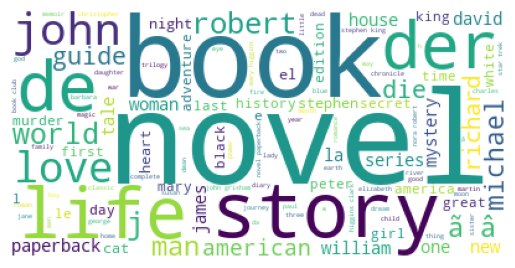

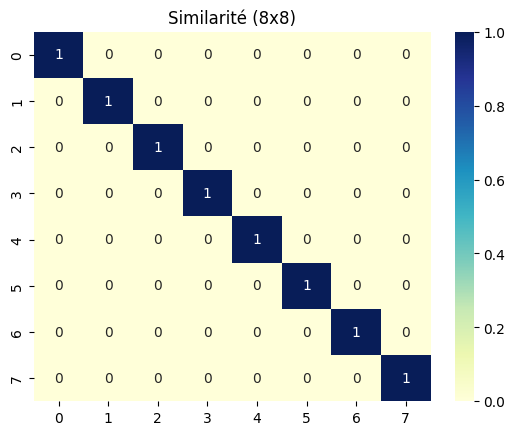

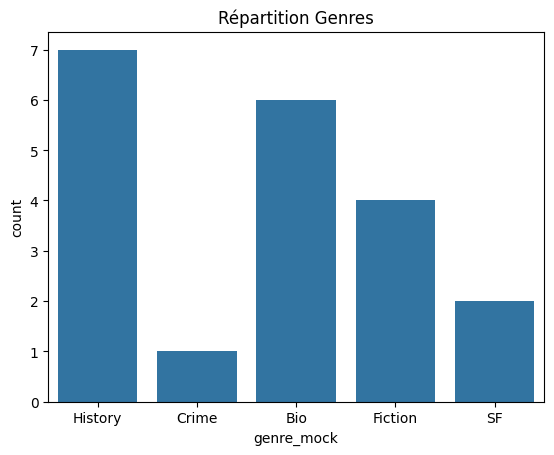

In [8]:
# 1. Nuage de mots
wc = WordCloud(background_color='white').generate(" ".join(books_sample['clean_content']))
plt.imshow(wc)
plt.axis('off')
plt.show()

# 2. Heatmap (échantillon)
sns.heatmap(cosine_sim[:8, :8], annot=True, cmap='YlGnBu')
plt.title("Similarité (8x8)")
plt.show()

# 3. Histogramme Genres (Simulé)
mock_genres = ['Fiction', 'Bio', 'SF', 'History', 'Crime']
books_sample['genre_mock'] = [np.random.choice(mock_genres) for _ in range(len(books_sample))]
sns.countplot(data=books_sample.head(20), x='genre_mock')
plt.title("Répartition Genres")
plt.show()

## Partie I : Discussion
1. **Nouveaux utilisateurs** : Utiliser les 'Top Rated' globaux ou des questions de profil.
2. **Notes** : Multiplier le score de similarité par (Note_Moyenne / 10).
3. **Hybride** : Fusionner Content + Collaborative Filtering pour compenser les faiblesses respectives.